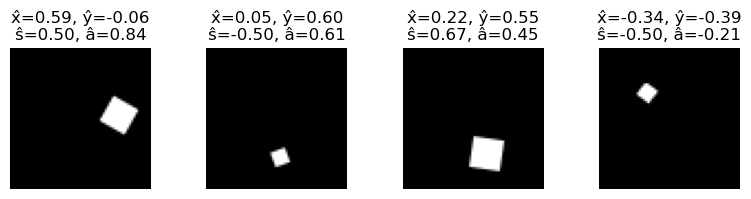

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate

# Parameters
#np.random.seed(0)
img_size     = 64
N            = 1000
min_size     = 4
max_size     = 16
angle_min    = 0.0
angle_max    = 360.0

# Global normalization bounds for centers, based on smallest possible patch
patch_size_min  = int(np.ceil(min_size * np.sqrt(2)))
half_patch_min  = patch_size_min / 2.0
cmin_global     = half_patch_min
cmax_global     = img_size - half_patch_min

# Preallocate
imgs        = np.zeros((N, img_size, img_size), dtype=float)
factors_raw = np.zeros((N, 4), dtype=float)  # [cx, cy, size, angle]
factors_norm= np.zeros((N, 4), dtype=float)  # all in [-1,1]

for i in range(N):
    # --- Sample raw generative factors ---
    size      = np.random.randint(min_size, max_size + 1)
    patch_size= int(np.ceil(size * np.sqrt(2)))
    half_patch= patch_size / 2.0

    # Center so rotated patch never clips
    cx = np.random.uniform(half_patch, img_size - half_patch)
    cy = np.random.uniform(half_patch, img_size - half_patch)
    angle = np.random.uniform(angle_min, angle_max)

    # Make patch with square at its center
    patch = np.zeros((patch_size, patch_size), dtype=float)
    offset = int(round(patch_size/2 - size/2))
    patch[offset:offset+size, offset:offset+size] = 1.0

    # Rotate patch around its own center
    patch_rot = rotate(
        patch, angle,
        reshape=False, order=1,
        mode='constant', cval=0.0
    )

    # Embed back into full-size image
    img = np.zeros((img_size, img_size), dtype=float)
    x0, y0 = int(round(cx - half_patch)), int(round(cy - half_patch))
    img[y0:y0+patch_size, x0:x0+patch_size] = patch_rot

    # Store raw
    imgs[i]        = img
    factors_raw[i] = [cx, cy, size, angle]

    # Normalize each factor to [-1,1]
    factors_norm[i,0] = 2*(cx   - cmin_global)/(cmax_global - cmin_global) - 1
    factors_norm[i,1] = 2*(cy   - cmin_global)/(cmax_global - cmin_global) - 1
    factors_norm[i,2] = 2*(size - min_size)/(max_size  - min_size)      - 1
    factors_norm[i,3] = 2*(angle- angle_min)/(angle_max - angle_min)    - 1

# Example visualization
fig, axes = plt.subplots(1, 4, figsize=(8,2))
for j, ax in enumerate(axes):
    idx = np.random.randint(0, N)
    ax.imshow(imgs[idx], cmap='gray', vmin=0, vmax=1)
    cn = factors_norm[idx]
    ax.set_title(
      f"x̂={cn[0]:.2f}, ŷ={cn[1]:.2f}\n"
      f"ŝ={cn[2]:.2f}, â={cn[3]:.2f}"
    )
    ax.axis('off')
plt.tight_layout()
plt.show()


In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import LocallyLinearEmbedding
X = imgs.reshape(N, -1)

# --- PCA and ICA ---
pca_emb = PCA(n_components=4, random_state=0).fit_transform(X)
ica_emb = FastICA(n_components=4, random_state=0, max_iter=500).fit_transform(X)

def compute_corr(factors, components):
    corrs = np.corrcoef(factors.T, components.T)[:4, 4:]
    return corrs

corr_pca = compute_corr(factors_norm, pca_emb)
corr_ica = compute_corr(factors_norm, ica_emb)

# --- HLLE and HLLE+ICA with parameter tuning ---
n_neighbors_list = [100]
dims_list = [4, 5, 6, 7]

# Initialize best trackers with corr=None to detect if any valid run occurs
best_hlle = {'score': -np.inf, 'corr': None, 'n_neighbors': None, 'dims': None}
best_hlle_ica = {'score': -np.inf, 'corr': None, 'n_neighbors': None, 'dims': None}

for n_neighbors in n_neighbors_list:
    for dims in dims_list:
        try:
            # Hessian LLE
            hlle = LocallyLinearEmbedding(n_neighbors=n_neighbors, n_components=dims,
                                          method='hessian', eigen_solver='dense')
            hlle_emb = hlle.fit_transform(X)
            corr_hlle = compute_corr(factors_norm, hlle_emb)
            score = np.sum(np.max(np.abs(corr_hlle), axis=1))
            if score > best_hlle['score']:
                best_hlle.update({'score': score, 'corr': corr_hlle,
                                  'n_neighbors': n_neighbors, 'dims': dims})

            # HLLE + ICA
            ica = FastICA(n_components=4, random_state=0, max_iter=500)
            hlle_ica_emb = ica.fit_transform(hlle_emb)
            corr_hlle_ica = compute_corr(factors_norm, hlle_ica_emb)
            score_ica = np.sum(np.max(np.abs(corr_hlle_ica), axis=1))
            if score_ica > best_hlle_ica['score']:
                best_hlle_ica.update({'score': score_ica, 'corr': corr_hlle_ica,
                                      'n_neighbors': n_neighbors, 'dims': dims})
        except ValueError:
            continue

# Safeguard: ensure 'corr' keys are present
if best_hlle['corr'] is None:
    raise RuntimeError("HLLE: No valid embedding found. Try expanding n_neighbors or dims ranges.")
if best_hlle_ica['corr'] is None:
    raise RuntimeError("HLLE+ICA: No valid embedding found. Try expanding n_neighbors or dims ranges.")

# Create DataFrames now that 'corr' exists
df_hlle = pd.DataFrame(best_hlle['corr'],
                       index=['cx','cy','size','angle'],
                       columns=[f'HLLE{i+1}' for i in range(best_hlle['dims'])])
df_hlle_ica = pd.DataFrame(best_hlle_ica['corr'],
                           index=['cx','cy','size','angle'],
                           columns=[f'IC{i+1}' for i in range(4)])

In [74]:
# 4. Create DataFrames
df_pca = pd.DataFrame(corr_pca,
                      index=['cx','cy','size','angle'],
                      columns=[f'PC{i+1}' for i in range(corr_pca.shape[1])])
df_ica = pd.DataFrame(corr_ica,
                      index=['cx','cy','size','angle'],
                      columns=[f'IC{i+1}' for i in range(corr_ica.shape[1])])

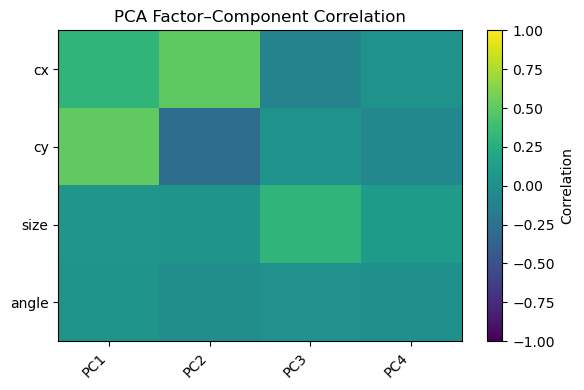

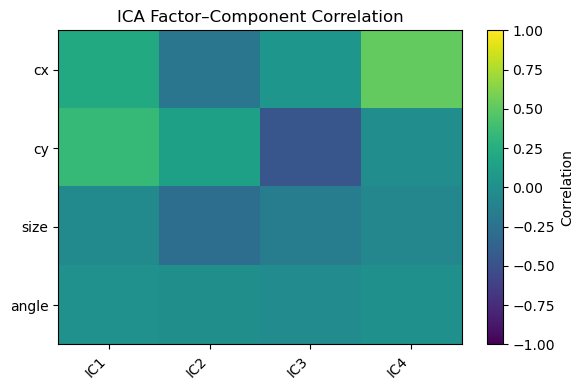

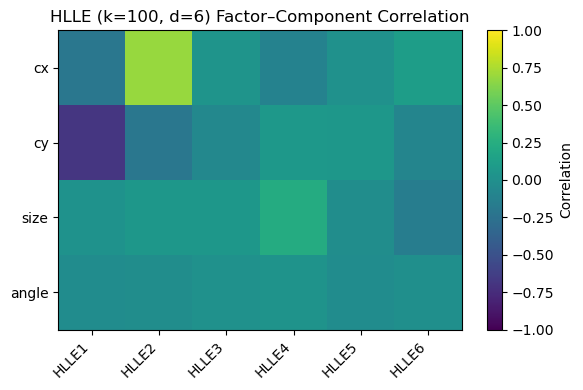

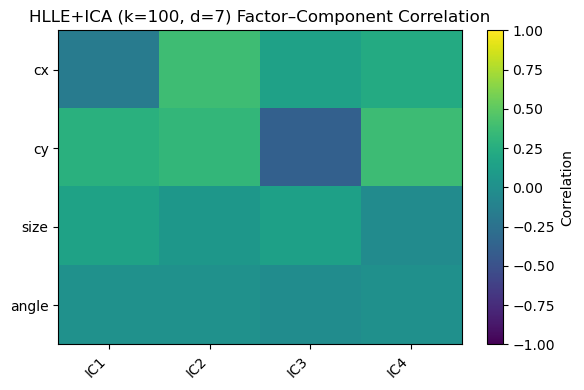

In [75]:
import matplotlib.pyplot as plt

# Pack titles and DataFrames together
plots = [
    ("PCA", df_pca),
    ("ICA", df_ica),
    (f"HLLE (k={best_hlle['n_neighbors']}, d={best_hlle['dims']})", df_hlle),
    (f"HLLE+ICA (k={best_hlle_ica['n_neighbors']}, d={best_hlle_ica['dims']})", df_hlle_ica)
]

for title, df in plots:
    plt.figure(figsize=(6,4))
    plt.imshow(df, vmin=-1, vmax=1, aspect='auto')
    plt.xticks(range(df.shape[1]), df.columns, rotation=45, ha='right')
    plt.yticks(range(df.shape[0]), df.index)
    plt.colorbar(label="Correlation")
    plt.title(f"{title} Factor–Component Correlation")
    plt.tight_layout()
    plt.show()


In [76]:
print("PCA Correlation Matrix", df_pca)
print("ICA Correlation Matrix", df_ica)
print(
    f"HLLE Correlation Matrix (k={best_hlle['n_neighbors']}, d={best_hlle['dims']})",
    df_hlle
)
print(
    f"HLLE+ICA Correlation Matrix (k={best_hlle_ica['n_neighbors']}, d={best_hlle_ica['dims']})",
    df_hlle_ica
)

PCA Correlation Matrix             PC1       PC2       PC3       PC4
cx     0.310064  0.507598 -0.103360  0.018463
cy     0.515296 -0.288239  0.029031 -0.063023
size   0.046580  0.032147  0.305372  0.109207
angle  0.032845 -0.014662  0.011383  0.006769
ICA Correlation Matrix             IC1       IC2       IC3       IC4
cx     0.218688 -0.214526  0.052087  0.517935
cy     0.338415  0.138918 -0.468186 -0.020320
size  -0.049055 -0.278255 -0.150367 -0.077074
angle  0.013590 -0.002087 -0.035779  0.000258
HLLE Correlation Matrix (k=100, d=6)           HLLE1     HLLE2     HLLE3     HLLE4     HLLE5     HLLE6
cx    -0.205862  0.692429  0.038073 -0.113816  0.009960  0.112564
cy    -0.683478 -0.203407 -0.068020  0.064328  0.057760 -0.088635
size   0.018359  0.058634  0.055368  0.227312 -0.017540 -0.151383
angle -0.029620 -0.019871  0.009442  0.025172 -0.027491 -0.003542
HLLE+ICA Correlation Matrix (k=100, d=7)             IC1       IC2       IC3       IC4
cx    -0.170278  0.382005  0.143058  0.2